# Lorenz sub-nodes (simul): per-node samples vs. component error — selected-epoch or best-over-epochs metrics snapshots

For every run under `LorenzCoCoMac/results_simul/...`,
we support two loading modes:
1. `SELECT_EPOCH = 2500` (or any integer): read exactly `metrics_snapshot_e{SELECT_EPOCH}.json`.
2. `SELECT_EPOCH = None` (default): scan all `metrics_snapshot_e*.json` files from epoch 1100 to 2500 and select the best snapshot for each metric family.

In auto-selection mode, **max** and **mean** use different criteria:
1. `component_max_err`: for every snapshot compute `max(self_x_corr2, self_y_corr2, self_z_corr2, msg_corr2)`, then convert the best snapshot to `1 - corr²` error.
2. `component_mean_err`: read `best_component_mean_err` from every snapshot and take the minimum value, because it is already an error.

The four per-component error curves (`self_x_err`, `self_y_err`, `self_z_err`, `msg_err`) come from the same snapshot selected by the **max corr²** criterion above. Lorenz stores `*_corr2` directly, so this notebook converts them to `1 - corr²` at load time.


In [1]:
import os, re, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

# Keep text as editable text (not outlined paths) in Adobe Illustrator.
plt.rcParams['svg.fonttype'] = 'none'   # SVG: text stays as <text>, editable in AI
plt.rcParams['pdf.fonttype'] = 42       # PDF: TrueType embed, editable in AI
plt.rcParams['ps.fonttype']  = 42       # EPS/PS: same, in case we ever export EPS

# Notebook lives at <repo>/LorenzCoCoMac/. cd there so RESULTS_DIR is a plain
# relative path even if the notebook is launched from elsewhere.
NB_BASENAME = 'analyze_subnodes_total_samples_vs_test_r2.ipynb'
NB_DIR = os.path.dirname(os.path.abspath(NB_BASENAME)) \
    if os.path.isfile(NB_BASENAME) else os.getcwd()
if os.path.basename(os.path.abspath(NB_DIR)) == 'LorenzCoCoMac':
    LORENZ_DIR = os.path.abspath(NB_DIR)
else:
    LORENZ_DIR = os.path.join(os.path.abspath(NB_DIR), 'LorenzCoCoMac')
os.chdir(LORENZ_DIR)

# Unified results dir: N=5 (epsilon=0.2) and N>5 (epsilon=0.1) are now mixed
# into the same folder. Folder names carry the N prefix, so there is no
# collision.
RESULTS_DIR = os.path.join(LORENZ_DIR, 'results_simul')
print('LORENZ_DIR :', LORENZ_DIR)
print('RESULTS_DIR:', RESULTS_DIR, '(exists)' if os.path.isdir(RESULTS_DIR) else '(MISSING)')


LORENZ_DIR : /DATA/sunyiting/figure4morestructure/LorenzCoCoMac
RESULTS_DIR: /DATA/sunyiting/figure4morestructure/LorenzCoCoMac/results_simul (exists)


In [2]:
# Only settings needed here: the run-name pattern plus (optionally) a node-size filter.
PATTERN = re.compile(
    r'^Nodes(?P<nodes>\d+)_Ntrain(?P<ntrain>\d+)_hidden(?P<hidden>\d+)_seed(?P<seed>\d+)$')

SCAN_NODE_SIZES = None   # None = use every N found on disk, otherwise e.g. {5, 10, 15, 20}
SELECT_EPOCH = None      # int -> use metrics_snapshot_e{epoch}.json; None -> auto-pick best over epochs
AUTO_EPOCH_MIN = 1100
AUTO_EPOCH_MAX = 2500
print(f'SELECT_EPOCH={SELECT_EPOCH}')
print(f'AUTO_EPOCH_RANGE=[{AUTO_EPOCH_MIN}, {AUTO_EPOCH_MAX}]')


SELECT_EPOCH=None
AUTO_EPOCH_RANGE=[1100, 2500]


In [3]:
# ===== Snapshot helpers =====
def list_snapshots(run_dir, epoch_min=AUTO_EPOCH_MIN, epoch_max=AUTO_EPOCH_MAX):
    """Return a sorted list of (epoch, path) for usable metrics snapshots."""
    out = []
    for path in glob.glob(os.path.join(run_dir, 'metrics_snapshot_e*.json')):
        m = re.search(r'e(\d+)', os.path.basename(path))
        if not m:
            continue
        ep = int(m.group(1))
        if epoch_min is not None and ep < epoch_min:
            continue
        if epoch_max is not None and ep > epoch_max:
            continue
        out.append((ep, path))
    return sorted(out)


def load_snapshot(path):
    with open(path) as f:
        return json.load(f)


def _corr2_to_err(c2):
    """1 - corr². Leaves NaN intact, clamps tiny negative values (numeric noise) to 0."""
    if c2 is None:
        return None
    v = 1.0 - float(c2)
    if np.isfinite(v) and v < 0 and v > -1e-9:
        return 0.0
    return v


def snapshot_component_payload(snap, epoch):
    sx = _corr2_to_err(snap.get('self_x_corr2'))
    sy = _corr2_to_err(snap.get('self_y_corr2'))
    sz = _corr2_to_err(snap.get('self_z_corr2'))
    mg = _corr2_to_err(snap.get('msg_corr2'))
    if any(v is None for v in (sx, sy, sz, mg)):
        return None
    corr_vals = [snap.get('self_x_corr2'), snap.get('self_y_corr2'), snap.get('self_z_corr2'), snap.get('msg_corr2')]
    corr_vals = [float(v) for v in corr_vals if v is not None]
    max_corr2 = float(np.nanmax(corr_vals)) if corr_vals else float(np.nanmax([1.0 - sx, 1.0 - sy, 1.0 - sz, 1.0 - mg]))
    return {
        'epoch': int(epoch),
        'self_x_err': float(sx),
        'self_y_err': float(sy),
        'self_z_err': float(sz),
        'msg_err': float(mg),
        'component_max_err': float(np.nanmax([sx, sy, sz, mg])),
        'component_mean_err_from_components': float(np.nanmean([sx, sy, sz, mg])),
        'max_corr2': max_corr2,
        'component_mean_err': snap.get('component_mean_err'),
        'best_component_mean_err': snap.get('best_component_mean_err'),
        'overall_r2': snap.get('overall_r2'),
        'node_r2_mean': snap.get('node_r2_mean'),
        'AUC': snap.get('AUC'),
        'AUPRC': snap.get('AUPRC'),
    }


def select_run_metrics(run_dir, select_epoch=SELECT_EPOCH):
    snaps = list_snapshots(run_dir)
    if not snaps:
        return None, 'no_snapshot'

    payloads = []
    for ep, path in snaps:
        if select_epoch is not None and ep != int(select_epoch):
            continue
        payload = snapshot_component_payload(load_snapshot(path), ep)
        if payload is not None:
            payloads.append(payload)

    if not payloads:
        if select_epoch is not None:
            return None, f'missing_epoch_{select_epoch}'
        return None, 'missing_component'

    if select_epoch is not None:
        chosen = payloads[0]
        return {
            'epoch_used_max': chosen['epoch'],
            'epoch_used_mean': chosen['epoch'],
            'selection_mode': f'fixed_e{chosen["epoch"]}',
            'self_x_err': chosen['self_x_err'],
            'self_y_err': chosen['self_y_err'],
            'self_z_err': chosen['self_z_err'],
            'msg_err': chosen['msg_err'],
            'component_max_err': chosen['component_max_err'],
            'component_mean_err': float(chosen.get('component_mean_err', chosen['component_mean_err_from_components'])),
            'component_mean_err_from_components': chosen['component_mean_err_from_components'],
            'component_mean_err_snap': chosen.get('component_mean_err'),
            'best_component_mean_err_selected': float(chosen.get('best_component_mean_err', chosen.get('component_mean_err', chosen['component_mean_err_from_components']))),
            'max_corr2_selected': chosen['max_corr2'],
            'overall_r2': chosen.get('overall_r2'),
            'node_r2_mean': chosen.get('node_r2_mean'),
            'AUC': chosen.get('AUC'),
            'AUPRC': chosen.get('AUPRC'),
        }, None

    best_max = max(payloads, key=lambda x: (x['max_corr2'], -x['epoch']))
    mean_candidates = [p for p in payloads if p.get('best_component_mean_err') is not None]
    if mean_candidates:
        best_mean = min(mean_candidates, key=lambda x: (float(x['best_component_mean_err']), x['epoch']))
        component_mean_err = float(best_mean['best_component_mean_err'])
        epoch_used_mean = int(best_mean['epoch'])
    else:
        best_mean = min(payloads, key=lambda x: (x['component_mean_err_from_components'], x['epoch']))
        component_mean_err = float(best_mean['component_mean_err_from_components'])
        epoch_used_mean = int(best_mean['epoch'])

    return {
        'epoch_used_max': int(best_max['epoch']),
        'epoch_used_mean': epoch_used_mean,
        'selection_mode': f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}',
        'self_x_err': best_max['self_x_err'],
        'self_y_err': best_max['self_y_err'],
        'self_z_err': best_max['self_z_err'],
        'msg_err': best_max['msg_err'],
        'component_max_err': best_max['component_max_err'],
        'component_mean_err': component_mean_err,
        'component_mean_err_from_components': best_max['component_mean_err_from_components'],
        'component_mean_err_snap': best_max.get('component_mean_err'),
        'best_component_mean_err_selected': component_mean_err,
        'max_corr2_selected': best_max['max_corr2'],
        'overall_r2': best_max.get('overall_r2'),
        'node_r2_mean': best_max.get('node_r2_mean'),
        'AUC': best_max.get('AUC'),
        'AUPRC': best_max.get('AUPRC'),
    }, None


In [4]:
# Walk every run dir, read fixed-epoch or best-over-epochs metrics, convert corr² -> err.
rows = []
skipped = 0
skipped_reasons = {}
for entry in sorted(os.listdir(RESULTS_DIR)):
    full = os.path.join(RESULTS_DIR, entry)
    if not os.path.isdir(full):
        continue
    m = PATTERN.match(entry)
    if not m:
        continue
    num_nodes = int(m.group('nodes'))
    if SCAN_NODE_SIZES is not None and num_nodes not in SCAN_NODE_SIZES:
        continue
    num_train = int(m.group('ntrain'))
    hidden = int(m.group('hidden'))
    seed = int(m.group('seed'))


    selected, reason = select_run_metrics(full, select_epoch=SELECT_EPOCH)
    if selected is None:
        skipped += 1
        skipped_reasons[reason] = skipped_reasons.get(reason, 0) + 1
        continue


    rows.append({
        'run_name': entry,
        'num_nodes_keep': num_nodes,
        'num_train_samples': num_train,
        'total_samples': num_nodes * num_train,
        'hidden': hidden,
        'seed': seed,
        **selected,
    })

metrics_df = pd.DataFrame(rows)
print(f'loaded {len(metrics_df)} runs, skipped {skipped} {skipped_reasons}')
if len(metrics_df):
    print('node sizes :', sorted(metrics_df.num_nodes_keep.unique()))
    print('seeds      :', sorted(metrics_df.seed.unique()))
    print('epoch_used_max range :', metrics_df.epoch_used_max.min(), '-', metrics_df.epoch_used_max.max())
    print('epoch_used_mean range:', metrics_df.epoch_used_mean.min(), '-', metrics_df.epoch_used_mean.max())
    if SELECT_EPOCH is not None:
        diff = (metrics_df['component_mean_err'] - metrics_df['component_mean_err_snap']).abs().max()
        print(f'max |component_mean_err - snap component_mean_err| = {diff:.3e}')
    else:
        print('auto mode: component_max_err/per-component and component_mean_err may come from different epochs per run')
metrics_df.head()


loaded 1665 runs, skipped 0 {}
node sizes : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 58]
seeds      : [1, 2, 3, 4, 5]
epoch_used_max range : 1100 - 2500
epoch_used_mean range: 1100 - 2500
auto mode: component_max_err/per-component and component_mean_err may come from different epochs per run


,run_name,num_nodes_keep,num_train_samples,total_samples,hidden,seed,epoch_used_max,epoch_used_mean,selection_mode,self_x_err,...,component_max_err,component_mean_err,component_mean_err_from_components,component_mean_err_snap,best_component_mean_err_selected,max_corr2_selected,overall_r2,node_r2_mean,AUC,AUPRC
0,Nodes10_Ntrain11_hidden50_seed1,10,11,110,50,1,2300,2400,best_e1100_2500,0.002386,...,0.605950,0.162722,0.163123,0.163123,0.162722,0.997614,0.980496,0.980300,0.843571,0.617579
1,Nodes10_Ntrain11_hidden50_seed2,10,11,110,50,2,2500,2400,best_e1100_2500,0.003942,...,0.664217,0.180633,0.182054,0.182054,0.180633,0.996058,0.972550,0.972328,0.822143,0.574868
2,Nodes10_Ntrain11_hidden50_seed3,10,11,110,50,3,2500,2400,best_e1100_2500,0.002481,...,0.664341,0.176744,0.179390,0.179390,0.176744,0.997519,0.976155,0.975991,0.837857,0.570523
3,Nodes10_Ntrain11_hidden50_seed4,10,11,110,50,4,2500,2000,best_e1100_2500,0.002313,...,0.758040,0.195759,0.205371,0.205371,0.195759,0.997687,0.973040,0.972869,0.814286,0.467869
4,Nodes10_Ntrain11_hidden50_seed5,10,11,110,50,5,2500,2500,best_e1100_2500,0.005128,...,0.641720,0.179446,0.180808,0.180808,0.179446,0.994872,0.965960,0.965730,0.833571,0.599078


In [5]:


# Aggregate over seeds for every (N, num_train_samples) cell.
ERR_COLS = ['self_x_err', 'self_y_err', 'self_z_err', 'msg_err',
            'component_mean_err', 'component_max_err']

agg_kw = {}
for c in ERR_COLS:
    agg_kw[f'mean_{c}'] = (c, 'mean')
    agg_kw[f'std_{c}']  = (c, 'std')
agg_kw['count'] = ('component_mean_err', 'count')

agg = (metrics_df.groupby(['num_nodes_keep', 'num_train_samples'])
                  .agg(**agg_kw)
                  .reset_index()
                  .sort_values(['num_nodes_keep', 'num_train_samples']))
agg['total_samples'] = agg['num_nodes_keep'] * agg['num_train_samples']

node_counts = sorted(metrics_df.num_nodes_keep.unique())
print('node sizes :', node_counts)
print('rows total :', len(agg))
agg.head()


node sizes : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 58]
rows total : 333


,num_nodes_keep,num_train_samples,mean_self_x_err,std_self_x_err,mean_self_y_err,std_self_y_err,mean_self_z_err,std_self_z_err,mean_msg_err,std_msg_err,mean_component_mean_err,std_component_mean_err,mean_component_max_err,std_component_max_err,count,total_samples
0,5,5,0.114883,0.069050,0.956362,0.025643,0.306479,0.036172,0.902177,0.060686,0.569729,0.027422,0.965675,0.016332,5,25
1,5,7,0.035881,0.021492,0.341584,0.048682,0.079782,0.018351,0.935613,0.056479,0.340514,0.011524,0.935613,0.056479,5,35
2,5,9,0.012939,0.009520,0.127304,0.013713,0.041950,0.010873,0.927255,0.039330,0.274295,0.010139,0.927255,0.039330,5,45
3,5,11,0.006835,0.003819,0.058478,0.010550,0.028335,0.005662,0.624478,0.164350,0.178411,0.041595,0.624478,0.164350,5,55
4,5,13,0.014292,0.004206,0.085759,0.012929,0.017751,0.003481,0.879180,0.072802,0.243891,0.021624,0.879180,0.072802,5,65


In [6]:
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
_cmap = LinearSegmentedColormap.from_list(
    'hr_nodes', ['#ca9a96', '#8d7e95', '#56648a', '#6280a5', '#8ca5c0'])
node_color = {
    n: to_hex(_cmap(i / max(len(node_counts) - 1, 1)))
    for i, n in enumerate(node_counts)
}


## Per node-size: per-node samples vs. selected component error

Two plots per node size, side by side:
- **left:** `component_mean_err` vs. `num_train_samples`.
  In auto mode this is the minimum `best_component_mean_err` over epochs.
- **right:** `component_max_err` vs. `num_train_samples`.
  In auto mode this comes from the snapshot with the largest `max(self_x_corr2, self_y_corr2, self_z_corr2, msg_corr2)`.

Lines = mean across seeds, shaded band = ±1 std (where ≥2 seeds available).


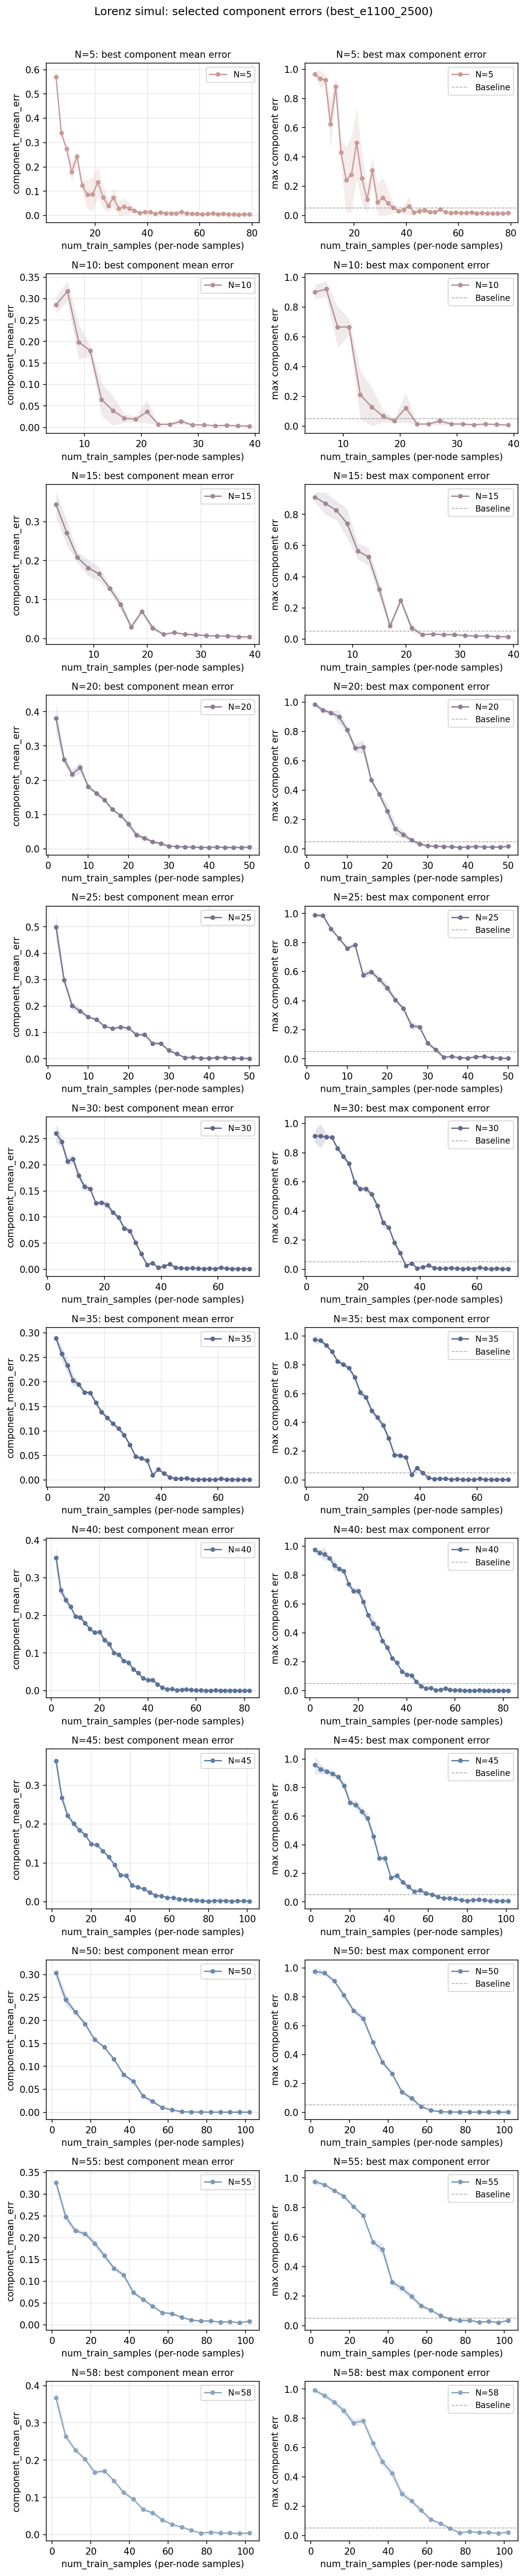

In [7]:
n_rows = len(node_counts)
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(8, 3.2 * n_rows),
                         sharex=False, sharey=False, dpi=150)
if n_rows == 1:
    axes = np.array([axes])

for r, n in enumerate(node_counts):
    s = agg[agg.num_nodes_keep == n].sort_values('num_train_samples')
    if s.empty:
        continue
    x = s['num_train_samples'].values
    c = node_color[n]

    ax = axes[r, 0]
    y = s['mean_component_mean_err'].values
    yerr = s['std_component_mean_err'].values
    ax.plot(x, y, 'o-', color=c, ms=4, lw=1.4, label=f'N={n}')
    ax.fill_between(x, np.clip(y - yerr, 0, None), y + yerr,
                    color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('component_mean_err')
    ax.set_title(f'N={n}: best component mean error', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='best')

    ax = axes[r, 1]
    y = s['mean_component_max_err'].values
    yerr = s['std_component_max_err'].values
    ax.plot(x, y, 'o-', color=c, ms=4, lw=1.4, label=f'N={n}')
    ax.fill_between(x, np.clip(y - yerr, 0, None), y + yerr,
                    color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('max component err')
    ax.set_title(f'N={n}: best max component error', fontsize=10)
    ax.axhline(0.05, color='gray', lw=0.8, ls='--', alpha=0.7, label='Baseline')
    ax.legend(fontsize=9, loc='best')

fig.suptitle(f'Lorenz simul: selected component errors ({plot_tag})',
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()


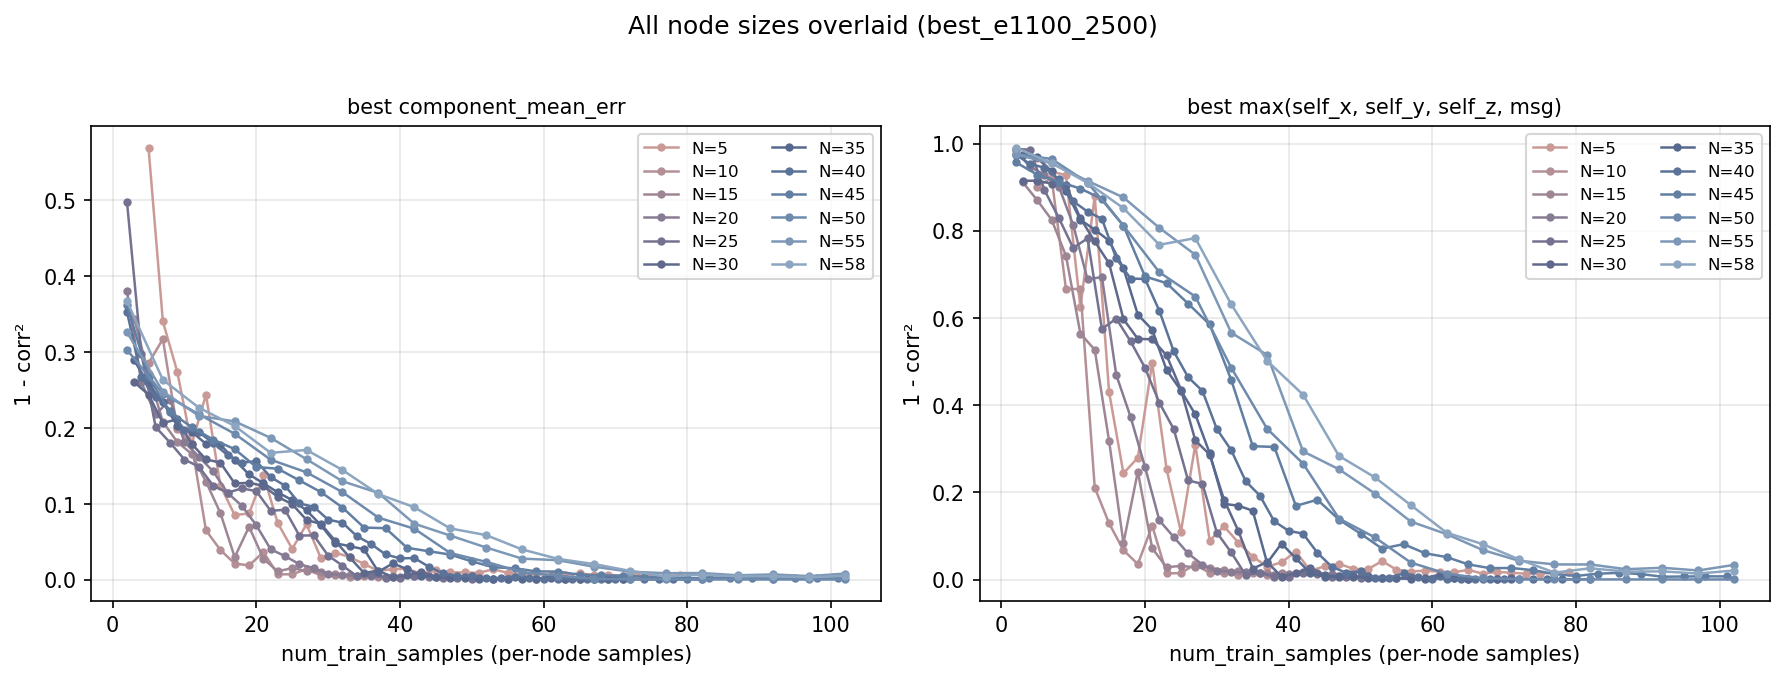

In [8]:
# Optional overlay: same two metrics but all node sizes on one axis.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), dpi=150)
for n in node_counts:
    s = agg[agg.num_nodes_keep == n].sort_values('num_train_samples')
    if s.empty:
        continue
    x = s['num_train_samples'].values
    c = node_color[n]
    axes[0].plot(x, s['mean_component_mean_err'].values, 'o-', color=c, ms=3, lw=1.2,
                 label=f'N={n}')
    axes[1].plot(x, s['mean_component_max_err'].values, 'o-', color=c, ms=3, lw=1.2,
                 label=f'N={n}')
for ax, title in zip(axes,
                     ['best component_mean_err', 'best max(self_x, self_y, self_z, msg)']):
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('1 - corr²')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best', ncol=2)
fig.suptitle(f'All node sizes overlaid ({plot_tag})', y=1.02)
fig.tight_layout()
plt.show()


### Phase diagram: $m_S$ vs $N$ for Lorenz simul

For each run we find **$m_S$** = the value of `num_train_samples` at which the
$\max(\mathrm{self\_x\_err},\mathrm{self\_y\_err},\mathrm{self\_z\_err},\mathrm{msg\_err})$
curve (i.e. the `component_max_err` column) first crosses a fixed baseline
$\varepsilon = 0.05$. In auto mode, `component_max_err` is taken from the epoch
that maximizes `max(self_x_corr2, self_y_corr2, self_z_corr2, msg_corr2)` for each run.

We scatter one point per (N, seed) plus a bar = mean over seeds. Two reference
curves are overlaid:
- $m_\mathrm{T} = N - 1$
- $m_\mathrm{D} = c / N$


In [9]:
def epsilon_S_crossing(xs, ys, y0):
    """Linear-interp x at which y(x) first crosses y0; nan if no crossing."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    if len(xs) < 2:
        return np.nan
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i + 1]
        if (y1 - y0) * (y2 - y0) <= 0 and y1 != y2:
            t = (y0 - y1) / (y2 - y1)
            return round(float(xs[i] + t * (xs[i + 1] - xs[i])), 2)
    return np.nan

baseline epsilon       = 0.1
c (user-specified)     = 140
crossover c/N vs N - 1 : N ≈ 12.34


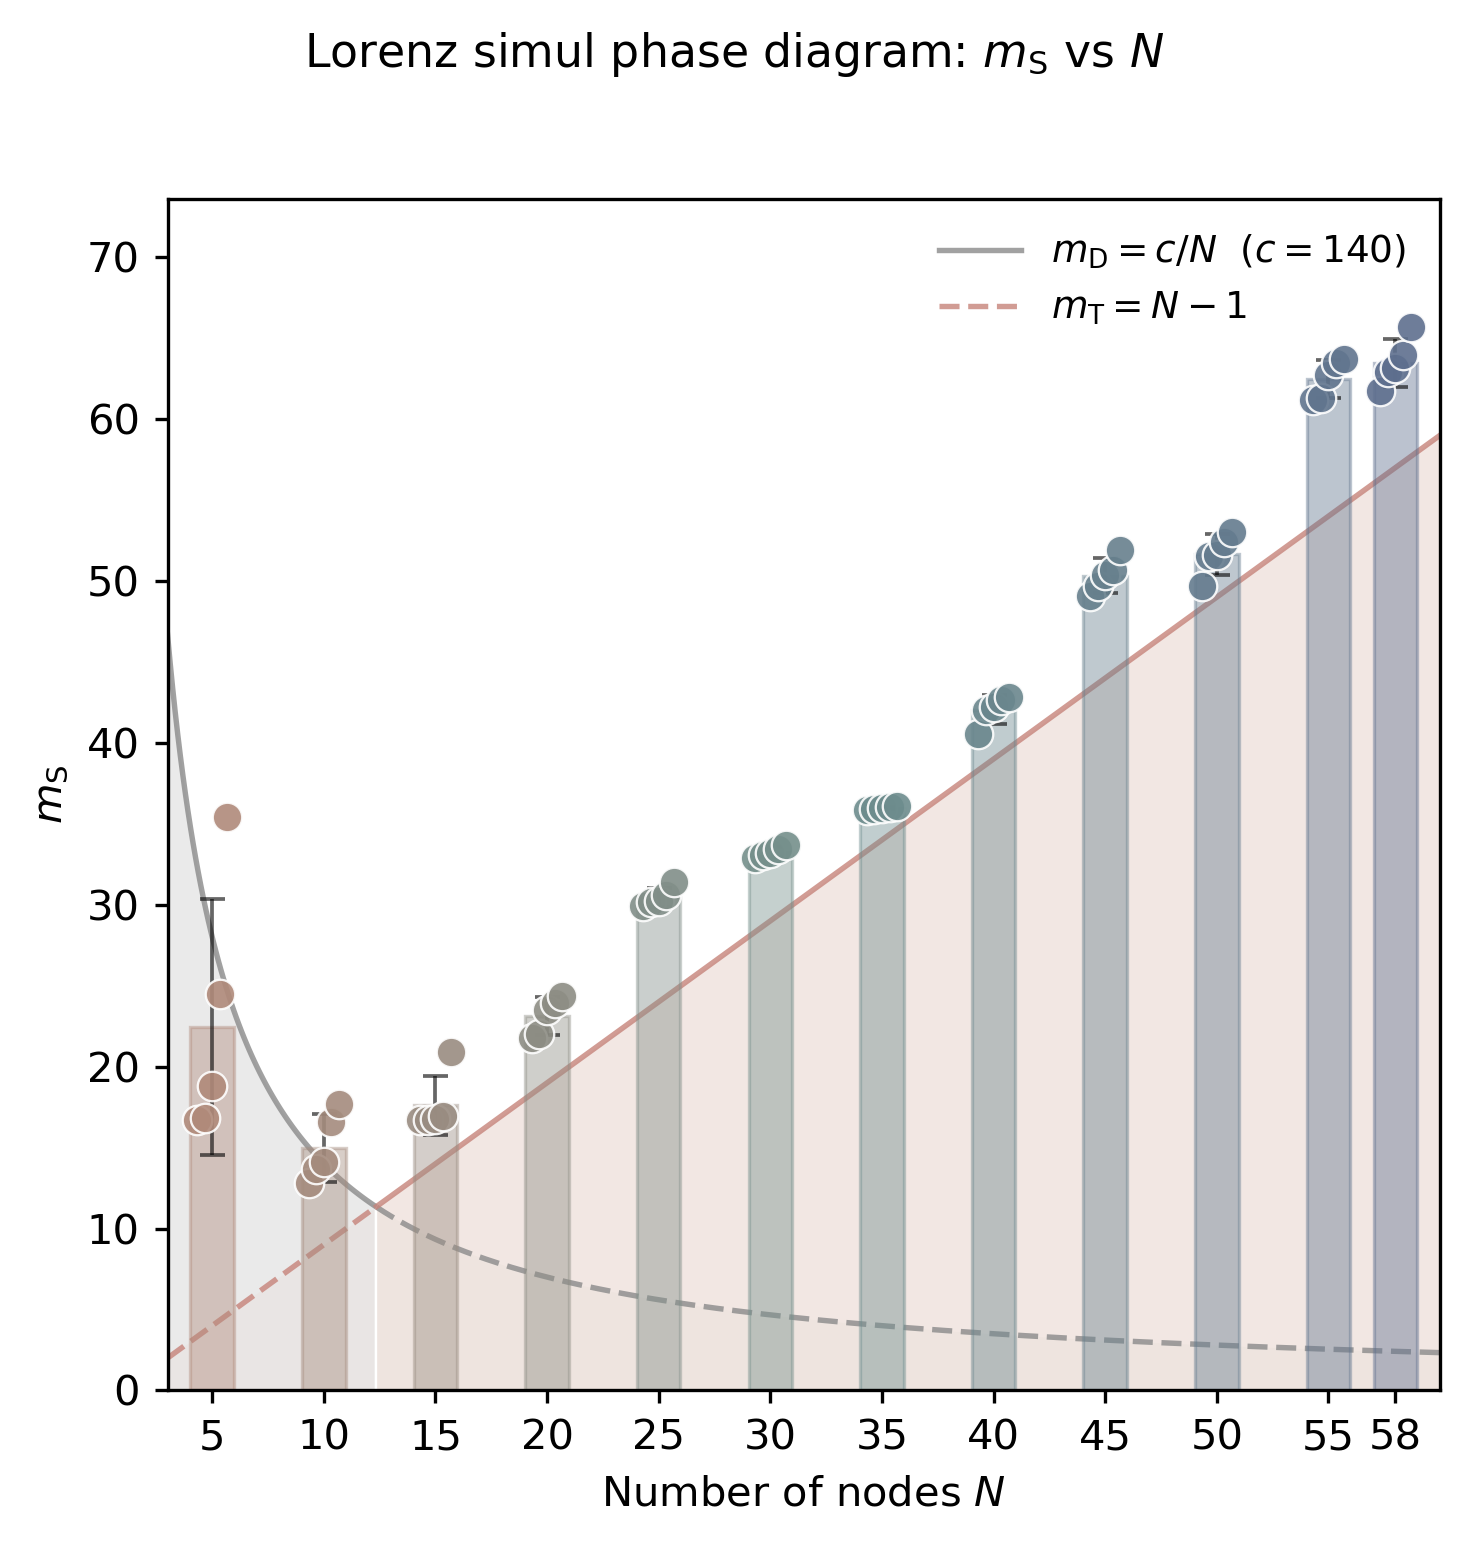

In [10]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
from scipy.optimize import brentq

# ---- phase-diagram settings ----
BASELINE = 0.1                    # crossing threshold on max-component err
ERR_COL  = 'component_max_err'     # max(self_x, self_y, self_z, msg) in 1-corr² units
C_FIT    = 140                     # user-specified constant for m_D = c / N overlay

seeds_sorted = sorted(metrics_df.seed.unique())

# 1) per-seed crossings -> grouped[N] = list of m_S values
grouped = {}
for n in node_counts:
    grouped[n] = []
    for seed in seeds_sorted:
        s = metrics_df[(metrics_df.num_nodes_keep == n)
                       & (metrics_df.seed == seed)].sort_values('num_train_samples')
        if s.empty:
            continue
        xc = epsilon_S_crossing(s.num_train_samples.values, s[ERR_COL].values, BASELINE)
        if np.isfinite(xc):
            grouped[n].append(float(xc))

# 2) crossover point c / N == N - 1 with user-specified c
try:
    x_cross_pt = brentq(lambda x: C_FIT / x - (x - 1), 1.5, 100)
except Exception:
    x_cross_pt = float(np.sqrt(C_FIT + 0.25) + 0.5)

print(f'baseline epsilon       = {BASELINE}')
print(f'c (user-specified)     = {C_FIT}')
print(f'crossover c/N vs N - 1 : N ≈ {x_cross_pt:.2f}')

# 3) style
COLORS = {
    "fill_inv":    "#D9D9D9",
    "line_inv":    "#8A8A8A",
    "fill_diag":   "#E8D5CD",
    "line_diag":   "#C6837A",
}
node_cmap = LinearSegmentedColormap.from_list(
    "nature_like_nodes", ["#B08A7A", "#6F8F8D", "#5E6F8E"])
node_to_color = {
    n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else "#6F8F8D"
    for i, n in enumerate(node_counts)
}

nc = np.array(node_counts, dtype=float)
min_gap = float(np.min(np.diff(nc))) if len(nc) > 1 else 2.0
BAR_WIDTH = min_gap * 0.65

# 4) plot
X_MIN, X_MAX = 3, 60
fig, ax = plt.subplots(figsize=(5.0, 5.0), dpi=300)

xref = np.linspace(X_MIN, X_MAX, 500)
mask_left  = xref <= x_cross_pt
mask_right = xref >  x_cross_pt
y_inv  = C_FIT / xref
y_diag = xref - 1

# filled regions, alpha flip at the crossover
ax.fill_between(xref[mask_left],  0, y_inv[mask_left],
                color=COLORS["fill_inv"],  alpha=0.55, linewidth=0, zorder=0)
ax.fill_between(xref[mask_right], 0, y_inv[mask_right],
                color=COLORS["fill_inv"],  alpha=0.20, linewidth=0, zorder=0)
ax.fill_between(xref[mask_left],  0, y_diag[mask_left],
                color=COLORS["fill_diag"], alpha=0.20, linewidth=0, zorder=0)
ax.fill_between(xref[mask_right], 0, y_diag[mask_right],
                color=COLORS["fill_diag"], alpha=0.55, linewidth=0, zorder=0)

# reference curves, solid on dominant side
ax.plot(xref[mask_left],  y_inv[mask_left],  color=COLORS["line_inv"], lw=1.3,
        ls='-',  alpha=0.8, zorder=1,
        label=rf'$m_\mathrm{{D}}=c/N$  ($c={C_FIT}$)')
ax.plot(xref[mask_right], y_inv[mask_right], color=COLORS["line_inv"], lw=1.3,
        ls='--', alpha=0.8, zorder=1)
ax.plot(xref[mask_left],  y_diag[mask_left],  color=COLORS["line_diag"], lw=1.3,
        ls='--', alpha=0.8, zorder=1, label=r'$m_\mathrm{T}=N-1$')
ax.plot(xref[mask_right], y_diag[mask_right], color=COLORS["line_diag"], lw=1.3,
        ls='-',  alpha=0.8, zorder=1)

# per-seed scatter + mean bar
for n in node_counts:
    vals = np.asarray(grouped.get(n, []), dtype=float)
    if len(vals) == 0:
        continue
    vals = np.sort(vals)
    jitter_half = BAR_WIDTH * 0.35
    offsets = (np.linspace(-jitter_half, jitter_half, len(vals))
               if len(vals) > 1 else np.array([0.0]))
    ax.scatter(n + offsets, vals, s=50, color=node_to_color[n],
               edgecolor='white', linewidth=0.55, alpha=0.9, zorder=5)

    mu = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    ax.bar(n, mu, width=BAR_WIDTH, color=node_to_color[n], alpha=0.42,
           edgecolor=node_to_color[n], linewidth=0.8, zorder=2)
    ax.errorbar(n, mu, yerr=sd, fmt='none', ecolor='black', elinewidth=0.9,
                capsize=3, capthick=0.9, alpha=0.6, zorder=4)

# axes / limits
ax.set_xlabel('Number of nodes $N$')
ax.set_ylabel('$m_\mathrm{S}$')
ax.set_xticks(node_counts)
ax.set_xlim(X_MIN, X_MAX)

all_vals = np.concatenate(
    [np.asarray(v, float) for v in grouped.values() if len(v)]
) if any(len(v) for v in grouped.values()) else np.array([])
ymax_candidates = [1.0]
if len(all_vals):
    ymax_candidates.append(float(np.nanmax(all_vals)))
ymax_candidates.append(float((nc - 1).max()))
ax.set_ylim(0, 1.12 * max(ymax_candidates))

# full frame (all four spines visible) instead of just left+bottom
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.8)
ax.tick_params(direction='out', length=3.2, width=0.8, top=False, right=False)
ax.legend(loc='upper right', frameon=False, fontsize=9, handlelength=2.2)

fig.suptitle(
    rf'Lorenz simul phase diagram: $m_\mathrm{{S}}$ vs $N$ ',
    y=1.02, fontsize=11)
fig.tight_layout()

# Save vector copies for Adobe Illustrator. Text stays editable thanks to the
# rcParams set in the imports cell (svg.fonttype='none', pdf.fonttype=42).
_out_base = os.path.join(LORENZ_DIR, f'phase_diagram_m_S_vs_N_eps{BASELINE}_c{C_FIT}')
# fig.savefig(_out_base + '.pdf', bbox_inches='tight')
# fig.savefig(_out_base + '.svg', bbox_inches='tight')
plt.show()